In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
# Load the dataset

df = pd.read_csv("House_Price_Prediction_Dataset_1000.csv")

# Display the first 5 rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,3219,1,1,3,2007,Urban,Excellent,Yes,1299445
1,2,1019,6,5,1,2017,Urban,Excellent,Yes,1141508
2,3,1552,5,5,1,2002,Rural,Average,No,798886
3,4,2439,5,3,1,2000,Rural,Good,No,989790
4,5,1236,2,2,1,1995,Suburban,Excellent,No,712461


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         1000 non-null   int64
 1   Area       1000 non-null   int64
 2   Bedrooms   1000 non-null   int64
 3   Bathrooms  1000 non-null   int64
 4   Floors     1000 non-null   int64
 5   YearBuilt  1000 non-null   int64
 6   Location   1000 non-null   str  
 7   Condition  1000 non-null   str  
 8   Garage     1000 non-null   str  
 9   Price      1000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 93.1 KB


In [4]:
# Shape of the dataset
df.shape

(1000, 10)

In [5]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='str')

In [6]:
# Missing values
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [7]:
# Duplicate values
df.duplicated().sum()

np.int64(0)

In [8]:
# Describe the dataset
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,500.500000,2562.076000,3.599000,2.388000,2.004000,2006.992000,1.105132e+06
std,288.819436,1137.740053,1.695604,1.271642,0.827447,9.894738,2.970589e+05
min,1.000000,600.000000,1.000000,1.000000,1.000000,1990.000000,3.215660e+05
25%,250.750000,1552.750000,2.000000,1.000000,1.000000,1998.750000,8.729618e+05
50%,500.500000,2577.000000,4.000000,2.000000,2.000000,2007.000000,1.096532e+06
75%,750.250000,3559.000000,5.000000,3.000000,3.000000,2015.000000,1.337189e+06
max,1000.000000,4499.000000,6.000000,5.000000,3.000000,2024.000000,1.850060e+06


In [9]:
# Display a random sample of 5 rows
df.sample(5)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
102,103,867,4,4,1,1993,Urban,Excellent,No,823322
399,400,1526,5,4,1,1990,Rural,Good,Yes,867103
835,836,2585,1,1,3,1994,Suburban,Good,Yes,950056
387,388,2945,3,3,3,1996,Urban,Good,Yes,1265074
761,762,4222,3,3,2,2000,Suburban,Good,Yes,1474056


# Data Preprocessing

In [10]:
# Remove unnecessary column

df = df.drop("Id", axis=1)

df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,3219,1,1,3,2007,Urban,Excellent,Yes,1299445
1,1019,6,5,1,2017,Urban,Excellent,Yes,1141508
2,1552,5,5,1,2002,Rural,Average,No,798886
3,2439,5,3,1,2000,Rural,Good,No,989790
4,1236,2,2,1,1995,Suburban,Excellent,No,712461


In [11]:
# Convert categorical columns into numerical values

df = pd.get_dummies(
    df,
    columns=["Location", "Condition", "Garage"],
    drop_first=True
)

df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Suburban,Location_Urban,Condition_Excellent,Condition_Good,Garage_Yes
0,3219,1,1,3,2007,1299445,False,True,True,False,True
1,1019,6,5,1,2017,1141508,False,True,True,False,True
2,1552,5,5,1,2002,798886,False,False,False,False,False
3,2439,5,3,1,2000,989790,False,False,False,True,False
4,1236,2,2,1,1995,712461,True,False,True,False,False


# Feature Selection and Target Variable

In [12]:
# Separate Features (X) and Target (y)

X = df.drop("Price", axis=1)
y = df["Price"]

In [13]:
X.head()    #no price will be shown

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Suburban,Location_Urban,Condition_Excellent,Condition_Good,Garage_Yes
0,3219,1,1,3,2007,False,True,True,False,True
1,1019,6,5,1,2017,False,True,True,False,True
2,1552,5,5,1,2002,False,False,False,False,False
3,2439,5,3,1,2000,False,False,False,True,False
4,1236,2,2,1,1995,True,False,True,False,False


In [14]:
y.head()

0    1299445
1    1141508
2     798886
3     989790
4     712461
Name: Price, dtype: int64

In [15]:
# Split training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 10), (200, 10), (800,), (200,))

# Train the Random Forest Regressor

In [17]:
# Random Forest model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [18]:
# Train the model

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

# Model Evaluation

In [19]:
# Predict house prices for the test data

y_pred = model.predict(X_test)

y_pred[:5]

array([1095928.31, 1110499.78, 1543270.7 , 1531990.24,  798093.29])

In [20]:
# R² Score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9447193354623198


In [37]:
# MAE

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 53584.709950000004


In [38]:
# RMSE

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 67298.12801159495


# Feature Importance

In [22]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Area,0.777233
1,Bedrooms,0.116788
6,Location_Urban,0.032433
4,YearBuilt,0.025999
2,Bathrooms,0.017174
7,Condition_Excellent,0.010247
3,Floors,0.006186
5,Location_Suburban,0.005843
9,Garage_Yes,0.005357
8,Condition_Good,0.002739


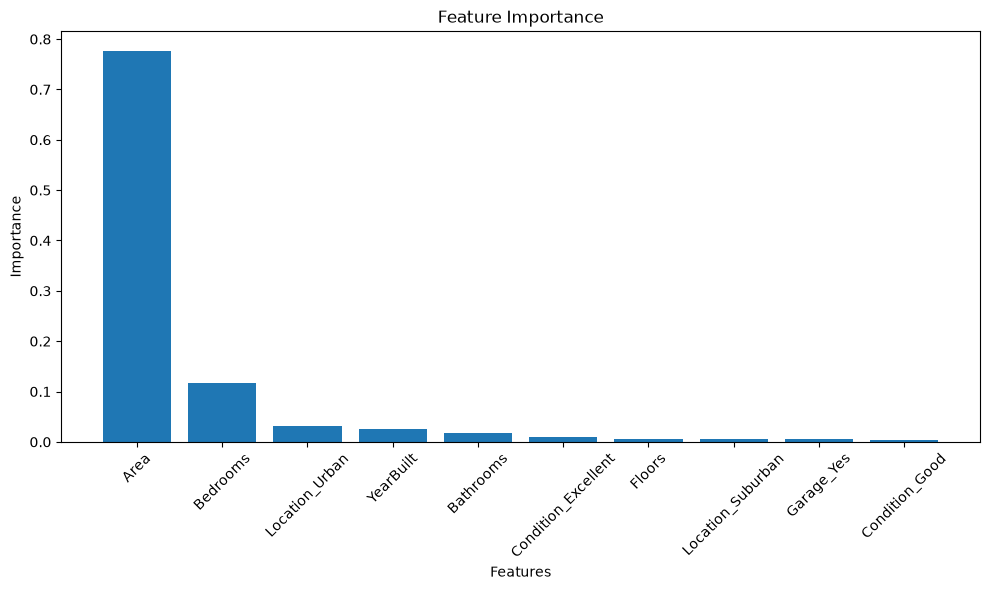

In [23]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.tight_layout()

plt.show()

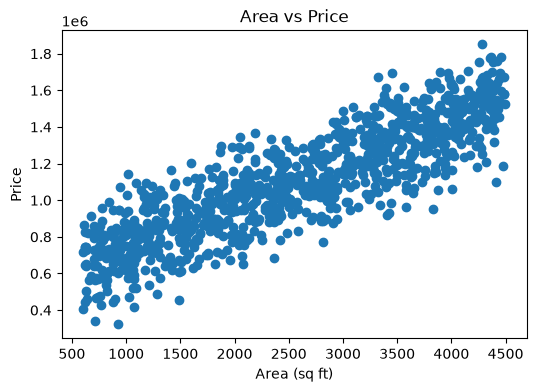

In [39]:
#Area vs Price Scatter Plot
plt.figure(figsize=(6,4))
plt.scatter(df["Area"], df["Price"])
plt.title("Area vs Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.show()

# Actual vs Predicted Prices

In [24]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,1054231,1095928.31
1,1082901,1110499.78
2,1548196,1543270.70
3,1659220,1531990.24
4,680819,798093.29
5,719073,758756.68
6,1532457,1492252.56
7,724128,740901.45
8,1363003,1294600.50
9,1200943,1050060.33


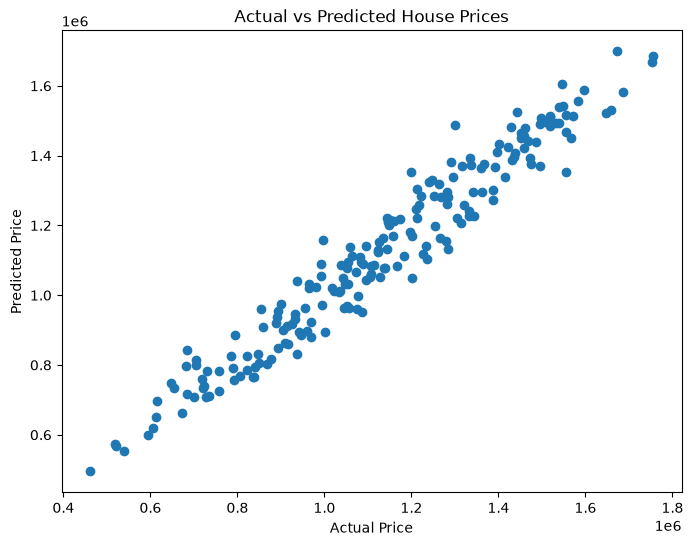

In [25]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

# Prediction Error

In [26]:
errors = y_test - y_pred

errors.head()

521    -41697.31
737    -27598.78
740      4925.30
660    127229.76
411   -117274.29
Name: Price, dtype: float64

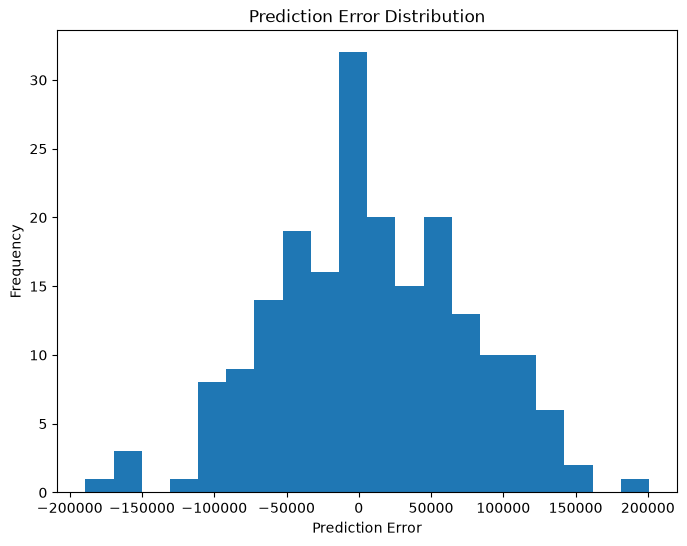

In [27]:
# Plot Error Distribution

plt.figure(figsize=(8,6))

plt.hist(errors, bins=20)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")

plt.show()

# Predict House Price Using User Input

In [29]:
# Create sample input

sample_house = pd.DataFrame({
    "Area": [2500],
    "Bedrooms": [4],
    "Bathrooms": [3],
    "Floors": [2],
    "YearBuilt": [2018],

    "Location_Suburban": [0],
    "Location_Urban": [1],

    "Condition_Excellent": [1],
    "Condition_Good": [0],

    "Garage_Yes": [1]
})

In [30]:
# Predict the house price

predicted_price = model.predict(sample_house)

print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))

Predicted House Price: ₹1,240,507.85


In [33]:
# User Input
area = float(input("Enter Area (sq ft): "))
bedrooms = int(input("Enter Number of Bedrooms: "))
bathrooms = int(input("Enter Number of Bathrooms: "))
floors = int(input("Enter Number of Floors: "))
year = int(input("Enter Year Built: "))

location = input("Enter Location (Urban/Suburban/Rural): ").strip().title()
condition = input("Enter Condition (Excellent/Good/Average): ").strip().title()
garage = input("Garage Available? (Yes/No): ").strip().title()

# Convert User Input to One-Hot Encoding

sample_house = pd.DataFrame({
    "Area": [area],
    "Bedrooms": [bedrooms],
    "Bathrooms": [bathrooms],
    "Floors": [floors],
    "YearBuilt": [year],

    "Location_Suburban": [1 if location == "Suburban" else 0],
    "Location_Urban": [1 if location == "Urban" else 0],

    "Condition_Excellent": [1 if condition == "Excellent" else 0],
    "Condition_Good": [1 if condition == "Good" else 0],

    "Garage_Yes": [1 if garage == "Yes" else 0]
})

# Predict House Price

predicted_price = model.predict(sample_house)

print("\nPredicted House Price: ₹{:,.2f}".format(predicted_price[0]))


Predicted House Price: ₹1,563,797.62
